In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from textblob import TextBlob
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('/kaggle/input/datasets/andrewmvd/trip-advisor-hotel-reviews/tripadvisor_hotel_reviews.csv')
print(df.shape)
df.head()

(20491, 2)


,Review,Rating
0,nice hotel expensive parking got good deal sta...,4
1,ok nothing special charge diamond member hilto...,2
2,nice rooms not 4* experience hotel monaco seat...,3
3,"unique, great stay, wonderful time hotel monac...",5
4,"great stay great stay, went seahawk game aweso...",5


In [3]:
print(df.info())
print("\nMissing values:")
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20491 entries, 0 to 20490
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Review  20491 non-null  object
 1   Rating  20491 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 320.3+ KB
None

Missing values:
Review    0
Rating    0
dtype: int64


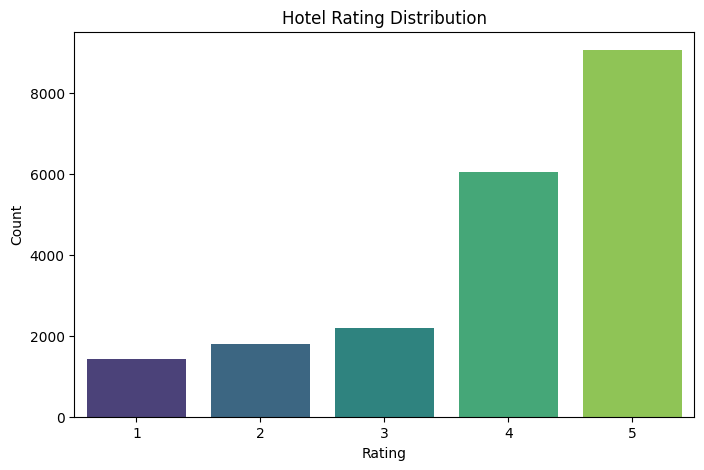

In [4]:
plt.figure(figsize=(8,5))
sns.countplot(x='Rating', data=df, palette='viridis')
plt.title('Hotel Rating Distribution')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.show()

In [5]:
df['sentiment'] = df['Review'].apply(lambda x: TextBlob(str(x)).sentiment.polarity)
df['sentiment_label'] = df['sentiment'].apply(lambda x: 'Positive' if x > 0 else ('Negative' if x < 0 else 'Neutral'))
df['sentiment_label'].value_counts()

sentiment_label
Positive    19112
Negative     1356
Neutral        23
Name: count, dtype: int64

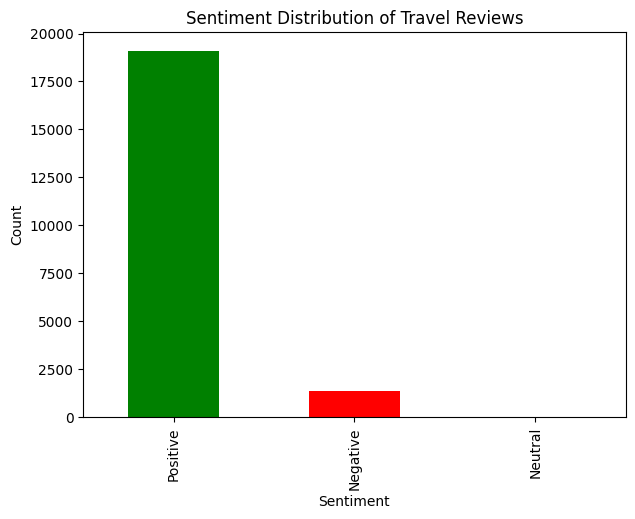

In [6]:
plt.figure(figsize=(7,5))
df['sentiment_label'].value_counts().plot(kind='bar', color=['green','red','gray'])
plt.title('Sentiment Distribution of Travel Reviews')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.show()

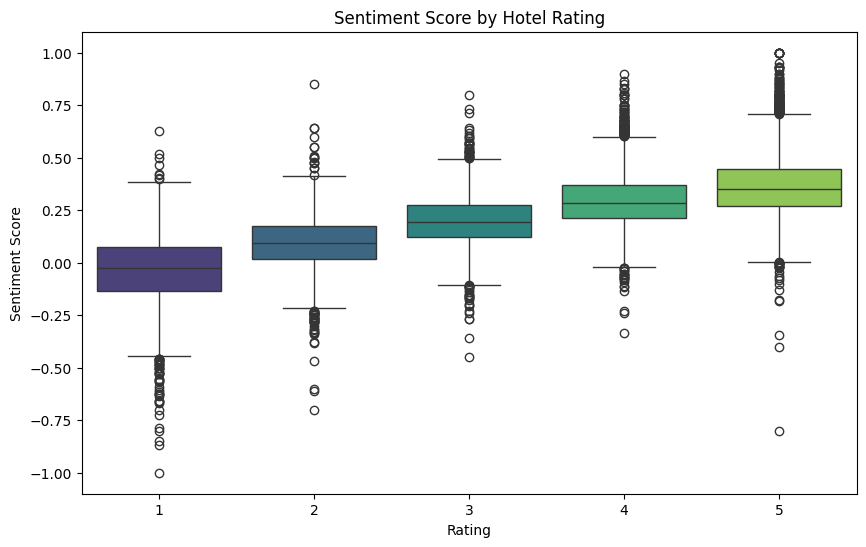

In [7]:
plt.figure(figsize=(10,6))
sns.boxplot(x='Rating', y='sentiment', data=df, palette='viridis')
plt.title('Sentiment Score by Hotel Rating')
plt.xlabel('Rating')
plt.ylabel('Sentiment Score')
plt.show()

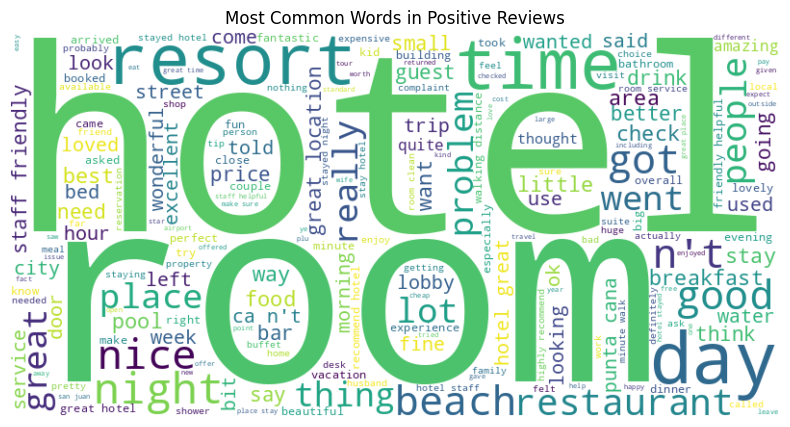

In [8]:
from wordcloud import WordCloud

positive_reviews = ' '.join(df[df['sentiment_label']=='Positive']['Review'].astype(str))
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(positive_reviews)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Most Common Words in Positive Reviews')
plt.show()

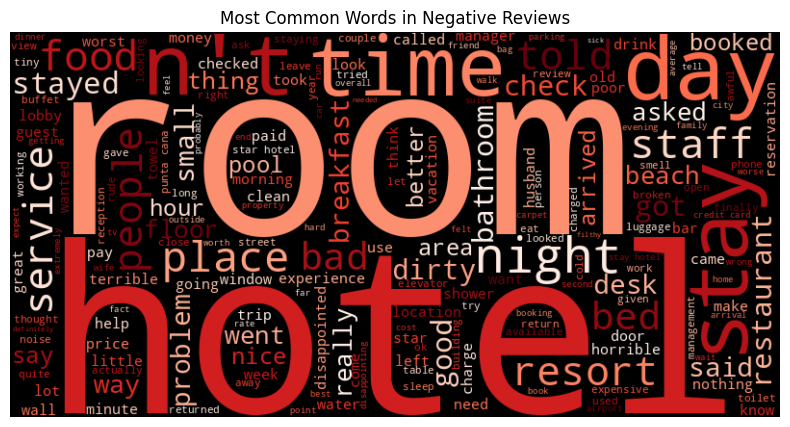

In [9]:
negative_reviews = ' '.join(df[df['sentiment_label']=='Negative']['Review'].astype(str))
wordcloud = WordCloud(width=800, height=400, background_color='black', colormap='Reds').generate(negative_reviews)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Most Common Words in Negative Reviews')
plt.show()

In [10]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns

# Prepare data
X = df['Review'].astype(str)
y = df['Rating']

# TF-IDF
tfidf = TfidfVectorizer(max_features=5000, stop_words='english')
X_tfidf = tfidf.fit_transform(X)

# Train test split
X_train, X_test, y_train, y_test = train_test_split(X_tfidf, y, test_size=0.2, random_state=42)

# Model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Results
y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.6316174676750427

Classification Report:
              precision    recall  f1-score   support

           1       0.80      0.62      0.70       292
           2       0.48      0.44      0.46       333
           3       0.46      0.24      0.32       432
           4       0.54      0.51      0.53      1252
           5       0.70      0.85      0.77      1790

    accuracy                           0.63      4099
   macro avg       0.60      0.53      0.55      4099
weighted avg       0.62      0.63      0.62      4099



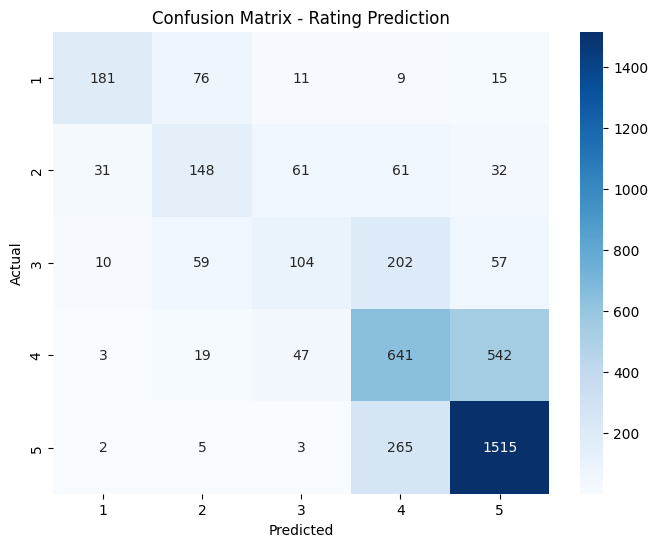

In [11]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[1,2,3,4,5],
            yticklabels=[1,2,3,4,5])
plt.title('Confusion Matrix - Rating Prediction')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [12]:
import pickle

with open('sentiment_model.pkl', 'wb') as f:
    pickle.dump(model, f)

with open('tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(tfidf, f)

print("Models saved!")

Models saved!


In [13]:
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.feature_extraction.text import CountVectorizer

# Vectorize
cv = CountVectorizer(max_features=1000, stop_words='english')
doc_term_matrix = cv.fit_transform(df['Review'].astype(str))

# LDA Model
lda = LatentDirichletAllocation(n_components=5, random_state=42)
lda.fit(doc_term_matrix)

# Top words per topic
words = cv.get_feature_names_out()
for i, topic in enumerate(lda.components_):
    print(f"\n🏷️ Topic {i+1}:")
    print([words[j] for j in topic.argsort()[-10:]])


🏷️ Topic 1:
['bed', 'rooms', 'desk', 'staff', 'service', 'night', 'stay', 'did', 'hotel', 'room']

🏷️ Topic 2:
['staff', 'stayed', 'rooms', 'good', 'room', 'nice', 'location', 'stay', 'great', 'hotel']

🏷️ Topic 3:
['beautiful', 'service', 'time', 'staff', 'good', 'pool', 'food', 'resort', 'great', 'beach']

🏷️ Topic 4:
['stayed', 'clean', 'stay', 'breakfast', 'good', 'staff', 'location', 'great', 'room', 'hotel']

🏷️ Topic 5:
['people', 'resort', 'got', 'good', 'just', 'water', 'beach', 'day', 'room', 'did']


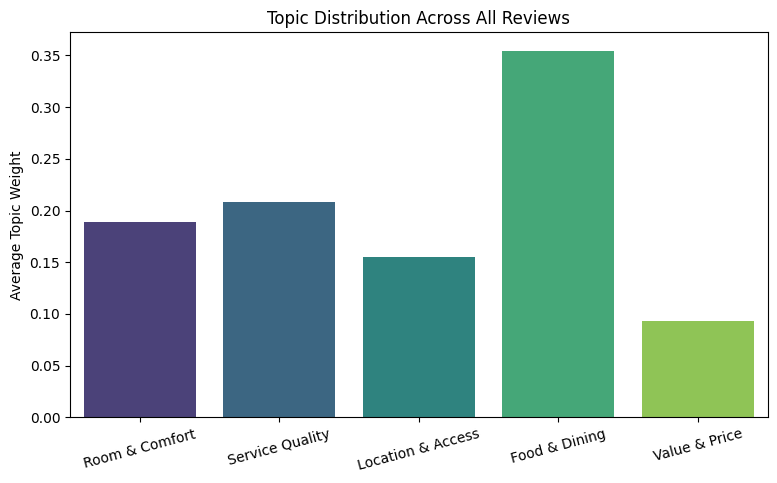

In [14]:
# Topic Distribution Chart
topic_names = ['Room & Comfort', 'Service Quality', 
               'Location & Access', 'Food & Dining', 
               'Value & Price']

topic_dist = lda.transform(doc_term_matrix).mean(axis=0)

plt.figure(figsize=(9,5))
sns.barplot(x=topic_names, y=topic_dist, palette='viridis')
plt.title('Topic Distribution Across All Reviews')
plt.ylabel('Average Topic Weight')
plt.xticks(rotation=15)
plt.show()

In [15]:
app_code = '''
import streamlit as st
import pickle
import matplotlib.pyplot as plt
from textblob import TextBlob
import pandas as pd

# Load model
with open('sentiment_model.pkl', 'rb') as f:
    model = pickle.load(f)
with open('tfidf_vectorizer.pkl', 'rb') as f:
    tfidf = pickle.load(f)

# Page config
st.set_page_config(page_title="Travel Sentiment Analyzer", page_icon="✈️", layout="wide")

st.title("✈️ Travel Review Sentiment Analyzer")
st.markdown("### AI-powered hotel review analysis")

# Input
review = st.text_area("Enter your hotel review:", height=150, 
                       placeholder="e.g. The hotel was amazing, great service and clean rooms!")

if st.button("Analyze Review 🔍"):
    if review:
        # Sentiment
        blob = TextBlob(review)
        sentiment_score = blob.sentiment.polarity
        
        if sentiment_score > 0:
            sentiment = "😊 Positive"
            color = "green"
        elif sentiment_score < 0:
            sentiment = "😞 Negative"  
            color = "red"
        else:
            sentiment = "😐 Neutral"
            color = "gray"
        
        # Rating prediction
        review_tfidf = tfidf.transform([review])
        predicted_rating = model.predict(review_tfidf)[0]
        
        # Display results
        col1, col2, col3 = st.columns(3)
        
        with col1:
            st.metric("Sentiment", sentiment)
        with col2:
            st.metric("Sentiment Score", f"{sentiment_score:.2f}")
        with col3:
            st.metric("Predicted Rating", f"⭐ {predicted_rating}/5")
            
        st.success("Analysis Complete!")
    else:
        st.warning("Please enter a review first!")
'''

with open('app.py', 'w') as f:
    f.write(app_code)

print("app.py created!")

app.py created!
